# Part A : Fundamentals


### What is Data Analysis?
Data Analysis is the process of collecting, cleaning, transforming, and interpreting data to extract meaningful insights and support decision-making.

It involves:

- Data collection from multiple sources
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Visualization and interpretation
- The goal is to identify patterns, trends, and relationships within the data

## Steps in a Data Science Project
1. Problem Definition
- Understand business objective
2. Data Collection
- Gather data from CSV, APIs, databases
3. Data Cleaning
- Handle missing values, duplicates, inconsistencies
4. Exploratory Data Analysis (EDA)
- Understand patterns and relationships
5. Feature Engineering
- Create new meaningful features
6. Model Building
- Train machine learning models
7. Model Evaluation
- Accuracy, precision, recall, etc.
8. Deployment
- Deploy model in real-world systems
9. Monitoring
- Track performance over time


## Machine Learning Problem Statement
Objective: To predict whether a customer will churn based on their purchase behavior and demographic features.

Type of Problem: Binary Classification (Churn = 0 or 1)

Input Features:

- Age
- Gender
- Income
- Purchase Amount
Target Variable:

- Churn (0 = No, 1 = Yes)
Goal: Build a predictive model that helps businesses identify customers at risk of leaving.

## What are Tensors?
Tensors are multi-dimensional arrays used in machine learning and deep learning.

Types:

- Scalar (0D): Single value → 5
- Vector (1D): [1, 2, 3]
- Matrix (2D): [[1,2],[3,4]]
- Higher dimensions: 3D, 4D tensors

Tensors are generalizations of matrices and are widely used in frameworks like TensorFlow and PyTorch.

import numpy as np

## Scalar (0D tensor)
scalar = np.array(5)

## Vector (1D tensor)
vector = np.array([1, 2, 3])

## Matrix (2D tensor)
matrix = np.array([[1, 2], [3, 4]])

## 3D Tensor
tensor_3d = np.array([ [[1,2],[3,4]], [[5,6],[7,8]] ])

print("Scalar:", scalar) 

print("Vector:", vector) 

print("Matrix:\n", matrix) 

print("3D Tensor:\n", tensor_3d)

# Part B: Data Acquisition

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import requests
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#CSV
df_csv = pd.read_csv("customer_data.csv")
print("CSV LOADED!!")
display(df_csv.head())

CSV LOADED!!


,CustomerID,Age,Gender,Income,PurchaseAmount,Churn
0,1,56,Male,56631,3082,0
1,2,46,Female,92991,3394,0
2,3,32,Female,24014,4829,0
3,4,25,Male,31093,1256,0
4,5,38,Female,38070,832,1


In [4]:
#JSON
df_json = pd.read_json('customer_data.json')
print("JSON LOADED!!")
display(df_json.head())

JSON LOADED!!


,CustomerID,Age,Gender,Income,PurchaseAmount,Churn
0,1,56,Male,56631,3082,0
1,2,46,Female,92991,3394,0
2,3,32,Female,24014,4829,0
3,4,25,Male,31093,1256,0
4,5,38,Female,38070,832,1


In [5]:
#SQL
conn = sqlite3.connect('customer_db.sqlite')
df_sql = pd.read_sql("SELECT * FROM customers", conn)
conn.close()
print("SQL LOADED!!")
display(df_sql.head())

SQL LOADED!!


,CustomerID,Age,Gender,Income,PurchaseAmount,Churn
0,1,56,Male,56631,3082,0
1,2,46,Female,92991,3394,0
2,3,32,Female,24014,4829,0
3,4,25,Male,31093,1256,0
4,5,38,Female,38070,832,1


In [8]:
#API 
url = "https://jsonplaceholder.typicode.com/users"
response = requests.get(url)
api_data = response.json()
df_api = pd.json_normalize(api_data)
print("API LOADED!!")
display(df_api.head())

API LOADED!!


,id,name,username,email,phone,website,address.street,address.suite,address.city,address.zipcode,address.geo.lat,address.geo.lng,company.name,company.catchPhrase,company.bs
0,1,Leanne Graham,Bret,Sincere@april.biz,1-770-736-8031 x56442,hildegard.org,Kulas Light,Apt. 556,Gwenborough,92998-3874,-37.3159,81.1496,Romaguera-Crona,Multi-layered client-server neural-net,harness real-time e-markets
1,2,Ervin Howell,Antonette,Shanna@melissa.tv,010-692-6593 x09125,anastasia.net,Victor Plains,Suite 879,Wisokyburgh,90566-7771,-43.9509,-34.4618,Deckow-Crist,Proactive didactic contingency,synergize scalable supply-chains
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net,1-463-123-4447,ramiro.info,Douglas Extension,Suite 847,McKenziehaven,59590-4157,-68.6102,-47.0653,Romaguera-Jacobson,Face to face bifurcated interface,e-enable strategic applications
3,4,Patricia Lebsack,Karianne,Julianne.OConner@kory.org,493-170-9623 x156,kale.biz,Hoeger Mall,Apt. 692,South Elvis,53919-4257,29.4572,-164.2990,Robel-Corkery,Multi-tiered zero tolerance productivity,transition cutting-edge web services
4,5,Chelsey Dietrich,Kamren,Lucio_Hettinger@annie.ca,(254)954-1289,demarco.info,Skiles Walks,Suite 351,Roscoeview,33263,-31.8129,62.5342,Keebler LLC,User-centric fault-tolerant solution,revolutionize end-to-end systems


In [7]:
#Combine datasets (CSV, JSON, SQL)
df_combined = pd.concat([df_csv, df_json, df_sql], ignore_index=True)

print("Combined Dataset Shape:", df_combined.shape)
df_combined.head()

Combined Dataset Shape: (420, 6)


,CustomerID,Age,Gender,Income,PurchaseAmount,Churn
0,1,56,Male,56631,3082,0
1,2,46,Female,92991,3394,0
2,3,32,Female,24014,4829,0
3,4,25,Male,31093,1256,0
4,5,38,Female,38070,832,1


# Part C: Data Understanding & Cleaning

In [8]:
#EDA
df = df_combined.copy()

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   CustomerID      420 non-null    int64 
 1   Age             420 non-null    int64 
 2   Gender          420 non-null    object
 3   Income          420 non-null    int64 
 4   PurchaseAmount  420 non-null    int64 
 5   Churn           420 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 19.8+ KB


In [10]:
df.describe()

,CustomerID,Age,Income,PurchaseAmount,Churn
count,420.000000,420.000000,420.000000,420.000000,420.000000
mean,96.214286,38.723810,60487.061905,2743.988095,0.304762
std,59.597911,12.549089,23662.751653,1412.041401,0.460855
min,1.000000,18.000000,20412.000000,109.000000,0.000000
25%,43.000000,28.000000,38683.750000,1463.250000,0.000000
50%,95.500000,40.000000,60856.500000,2879.000000,0.000000
75%,148.000000,49.250000,80597.500000,3948.500000,1.000000
max,200.000000,59.000000,99634.000000,4992.000000,1.000000


In [ ]:
#Missing values
print(df.isnull().sum())

CustomerID        0
Age               0
Gender            0
Income            0
PurchaseAmount    0
Churn             0
dtype: int64


# Part D: Exploratory Data Analysis(EDA)

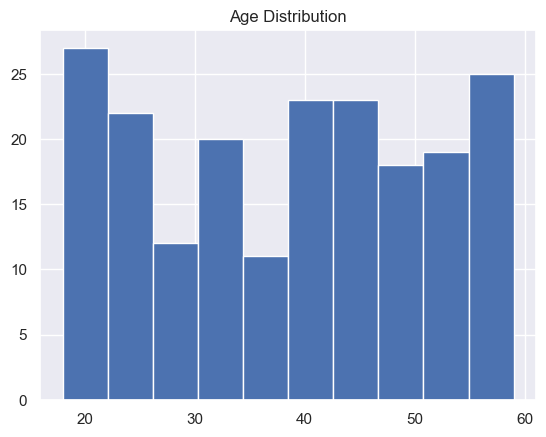

In [14]:
# Univariate
df['Age'].hist()
plt.title("Age Distribution")
plt.show()

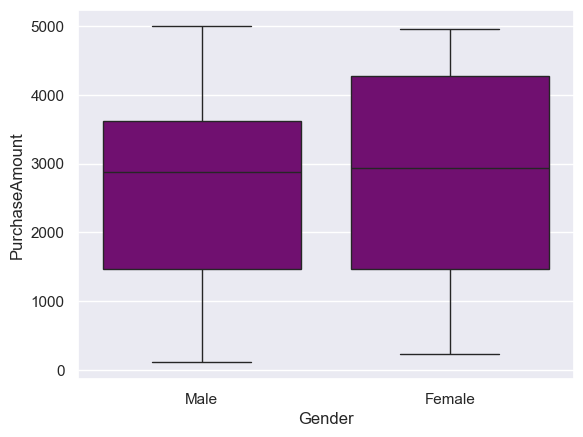

In [17]:
# Bivariate
sns.boxplot(x='Gender', y='PurchaseAmount', data=df , color="purple")
plt.show()

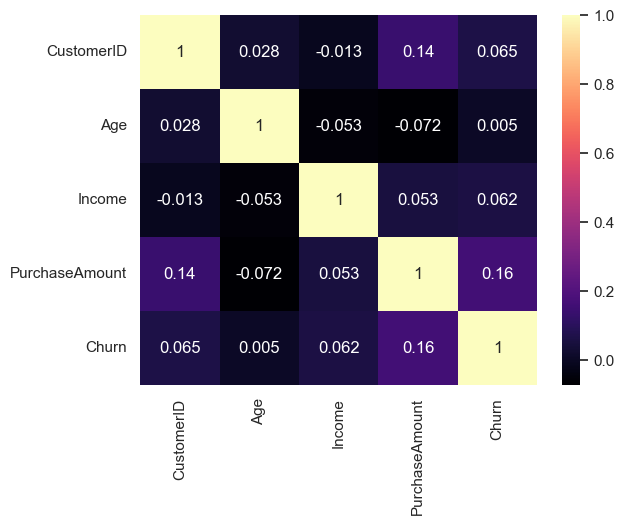

In [23]:
# Multivariate
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="magma")
plt.show()

In [24]:
#Feature Engineering
df['Income_per_Age'] = df['Income'] / df['Age']
print(df.head())

   CustomerID  Age  Gender  Income  PurchaseAmount  Churn  Income_per_Age
0           1   56    Male   56631            3082      0     1011.267857
1           2   46  Female   92991            3394      0     2021.543478
2           3   32  Female   24014            4829      0      750.437500
3           4   25    Male   31093            1256      0     1243.720000
4           5   38  Female   38070             832      1     1001.842105


In [25]:
#Feature Engineering
df['Income_per_Age'] = df['Income'] / df['Age']
print(df.tail())

     CustomerID  Age  Gender  Income  PurchaseAmount  Churn  Income_per_Age
195         196   23  Female   80566            3923      0     3502.869565
196         197   49  Female   86703            4142      0     1769.448980
197         198   21    Male   47192            2006      0     2247.238095
198         199   28  Female   21062             860      0      752.214286
199         200   34  Female   41545            3545      0     1221.911765


# Part E: Data Profiling

In [6]:
from ydata_profiling import ProfileReport

df = pd.read_csv("customer_data.csv")

profile = ProfileReport(df, title="Report", explorative=True)
profile.to_file("report.html")


Export report to file: 100%|██████████| 1/1 [00:00<00:00, 250.17it/s]


In [10]:
import webbrowser
webbrowser.open("report.html")

True